In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df['Churn'].value_counts())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# TotalCharges has hidden spaces, fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop customerID, it's useless
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Churn rate: {df['Churn'].mean():.2%}")

Missing values: 0
Churn rate: 26.58%


In [4]:
# Separate column types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Churn')

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

# Label encode all categoricals
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler + feature names for later use in Streamlit
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (5625, 19), Test size: (1407, 19)


In [6]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
Accuracy : 0.7939
F1 Score : 0.5927
ROC-AUC  : 0.8345


In [7]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)  # XGBoost doesn't need scaling

xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")

=== XGBoost ===
Accuracy : 0.7903
F1 Score : 0.5731
ROC-AUC  : 0.8346


In [8]:
joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')

# Save test data for use in Day 2 onwards
X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
X_train.to_csv('../data/X_train.csv', index=False)

print("All models saved successfully ✓")

All models saved successfully ✓


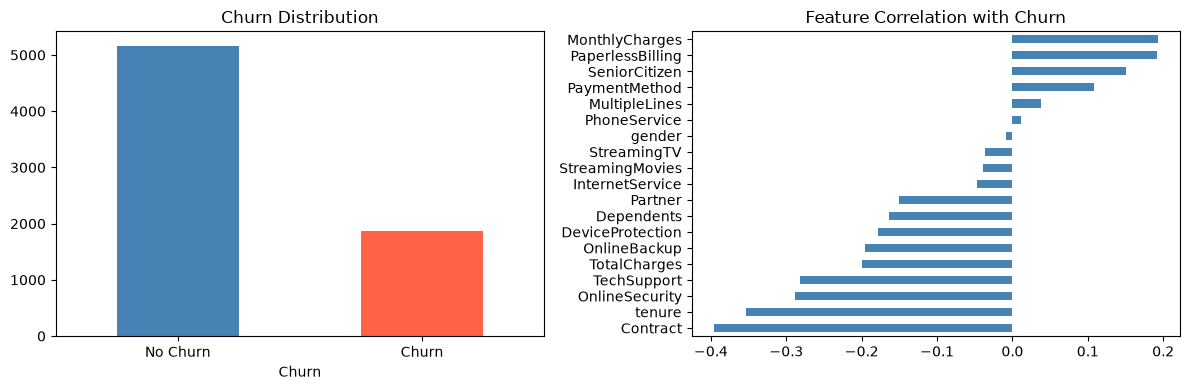

In [9]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Feature correlation with churn
correlations = df.corr()['Churn'].drop('Churn').sort_values()
correlations.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Correlation with Churn')

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150)
plt.show()